In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import spacy
from nltk.corpus import stopwords
from bertopic import BERTopic
from sklearn.linear_model              import LogisticRegression
from sklearn.model_selection           import cross_val_score, train_test_split
from sklearn.metrics                   import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text   import CountVectorizer
from hdbscan import HDBSCAN

/opt/anaconda3/envs/text-analytics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data preparation

In [12]:
df = pd.read_csv('data/reddit_posts.csv')

In [13]:
df['Date Created'] = pd.to_datetime(df['Date Created'], unit='s')

In [14]:
df = df.rename(columns={"Title": "title", "Text": "selftext"})

In [15]:
# posts containing at least one URL in title + selftext
combined = df['title'].fillna('') + ' ' + df['selftext'].fillna('')
url_pattern = r'https?://\S+'
has_url = combined.str.contains(url_pattern)
print(f"{has_url.sum()} posts contain URLs out of {len(df)} total")

# remove URLs from title and selftext
df['title']    = df['title'].str.replace(url_pattern, '', regex=True)
df['selftext'] = df['selftext'].str.replace(url_pattern, '', regex=True)

503 posts contain URLs out of 9999 total


In [16]:
# stop words list
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_str(text):
    if pd.isna(text):
        return ""
    # lowercase
    text = text.lower()
    # remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # split, filter out short tokens & stop-words, then re-join
    tokens = text.split()
    tokens = [w for w in tokens if len(w) >= 3 and w not in stop_words]
    return " ".join(tokens)

# Apply to title and body, storing cleaned strings
df['title']  = df['title'].apply(clean_str)
df['selftext']   = df['selftext'].apply(clean_str)

In [17]:
df['Political Lean'].value_counts()

Political Lean
Liberal         6426
Conservative    3573
Name: count, dtype: int64

## Topic Modeling

In [18]:
# Ensure selftext has no NaNs
df["selftext"] = df["selftext"].fillna("")

# Build docs by combining title + selftext (only if selftext isn’t empty)
docs = (
    df.apply(
        lambda row: row["title"] + " " + row["selftext"]
        if row["selftext"].strip() != ""
        else row["title"],
        axis=1,
    )
    .tolist()
)

y = df["Political Lean"].map({"Liberal": 0, "Conservative": 1})

2025-06-04 13:42:42,653 - BERTopic - Embedding - Transforming documents to embeddings.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Batches: 100%|██████████| 313/313 [00:57<00:00,  5.43it/s]
2025-06-04 13:44:10,320 - BERTopic - Embedding - Completed ✓
2025-06-04 13:44:10,321 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-04 13:44:13,816 - BERTopic - Dimensionality - Completed ✓
2025-06-04 13:44:13,817 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-04 13:44:17,686 - BERTopic - Cluster - Completed ✓
2025-06-04 13:44:17,687 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-06-04 13:44:17,844 - BERTopic - Representation - Completed ✓
2025-06-04 13:44:17,845 - BERTopic - Topic reduction - Reducing num

5-fold CV AUC: 0.638 ± 0.044
5-fold CV Balanced Accuracy: 0.581 ± 0.060
              precision    recall  f1-score   support

     Liberal       0.75      0.75      0.75      1285
Conservative       0.55      0.55      0.55       715

    accuracy                           0.68      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.68      0.68      0.68      2000



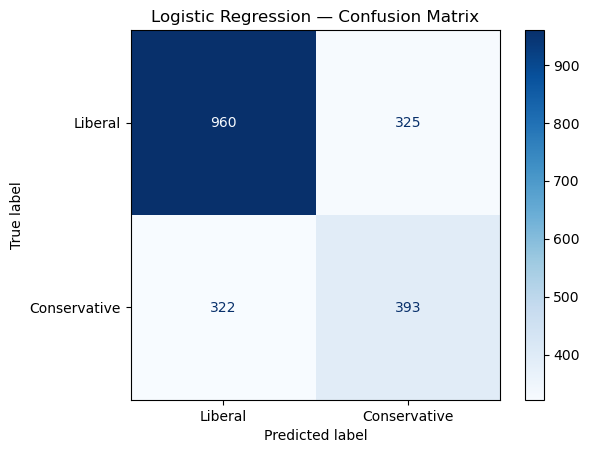

In [19]:
# Fit BERTopic with full probability matrix
topic_model = BERTopic(embedding_model="all-mpnet-base-v2", nr_topics=40, calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(docs)

# Evaluate with 5-fold CV AUC
X = np.array(probs)                     # shape: (n_docs, n_topics)
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
auc_scores = cross_val_score(clf, X, y, cv=5, scoring="roc_auc")
print(f"5-fold CV AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
bal_scores = cross_val_score(clf, X, y, cv=5, scoring="balanced_accuracy")
print(f"5-fold CV Balanced Accuracy: {bal_scores.mean():.3f} ± {bal_scores.std():.3f}")# better than accuracy metric because our classes are imbalanced

# Train/test split for confusion matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Liberal","Conservative"]))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Liberal","Conservative"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [20]:
# number of topics
n_topics = len(topic_model.get_topic_info()) - 1 # subtract 1 because get_topic_info() includes the “-1” outlier row
print(f"Brettopic found {n_topics} topics in the corpus.")

Brettopic found 39 topics in the corpus.


In [21]:
# Find top-skew topics per class
probs_df = pd.DataFrame(probs, columns=range(probs.shape[1]))
probs_df["class"] = y.values
mean_by_class = probs_df.groupby("class").mean()
diff = mean_by_class.loc[1] - mean_by_class.loc[0]

top_cons = diff.nlargest(5).index.tolist()
top_lib  = diff.nsmallest(5).index.tolist()

print("Top Conservative topics:", top_cons)
print("Top Liberal topics:     ", top_lib)

for tid in top_cons:
    print(f"\n=== Topic {tid} (Conservative) ===")
    for word, score in topic_model.get_topic(tid):
        print(f"  {word:15} {score:.4f}")

for tid in top_lib:
    print(f"\n=== Topic {tid} (Liberal) ===")
    for word, score in topic_model.get_topic(tid):
        print(f"  {word:15} {score:.4f}")

Top Conservative topics: [1, 2, 11, 19, 12]
Top Liberal topics:      [7, 13, 8, 4, 5]

=== Topic 1 (Conservative) ===
  ukraine         0.1043
  russia          0.0782
  russian         0.0486
  putin           0.0472
  nato            0.0335
  invasion        0.0287
  war             0.0271
  ukrainian       0.0254
  biden           0.0202
  conflict        0.0181

=== Topic 2 (Conservative) ===
  biden           0.1580
  court           0.0489
  supreme         0.0478
  trump           0.0440
  joe             0.0430
  poll            0.0325
  president       0.0258
  mcconnell       0.0242
  cheney          0.0242
  gop             0.0224

=== Topic 11 (Conservative) ===
  trudeau         0.1366
  canada          0.1122
  convoy          0.1029
  canadian        0.0679
  freedom         0.0504
  emergencies     0.0482
  truckers        0.0466
  trucker         0.0465
  ottawa          0.0426
  protests        0.0418

=== Topic 19 (Conservative) ===
  desantis        0.4366
  ron    

In [147]:
# Raw n-gram vocabulary comparison
vectorizer = CountVectorizer(stop_words="english", ngram_range=(1,2), max_features=5000)
X_cv = vectorizer.fit_transform(docs)
vocab = vectorizer.get_feature_names_out()

vocab_df = pd.DataFrame(X_cv.toarray(), columns=vocab)
vocab_df["class"] = y.values
counts = vocab_df.groupby("class").sum()

print("\nTop 20 terms (Liberal):")
print(counts.loc[0].nlargest(20), "\n")
print("Top 20 terms (Conservative):")
print(counts.loc[1].nlargest(20))


Top 20 terms (Liberal):
people        1297
like           991
party          892
right          838
worker         835
social         783
work           766
state          749
think          700
woman          664
trump          637
new            628
time           616
year           608
know           583
country        582
want           582
socialist      572
government     554
say            539
Name: 0, dtype: int64 

Top 20 terms (Conservative):
people         803
capitalism     471
trump          465
government     462
like           441
ukraine        422
biden          397
think          383
russia         368
right          349
state          344
work           341
say            312
good           284
want           284
libertarian    279
know           267
time           247
free           246
money          245
Name: 1, dtype: int64


In [148]:
import numpy as np
import pandas as pd

n = 5  # number of top posts per class to inspect

# 1) (Re)compute normalized score within each subreddit
df["norm_score"] = (
    df.groupby("Subreddit")["Score"]
    .transform(lambda x: x / x.max())
)

# 2) Build a DataFrame of topic probabilities + class + norm_score
probs_df = pd.DataFrame(probs, columns=[f"topic_{i}" for i in range(probs.shape[1])])
probs_df["class"]     = y.values
probs_df["norm_score"] = df["norm_score"].values

# 3) For each class, take the top n rows by norm_score
top_posts = {0: [], 1: []}
for cl in [0, 1]:
    subset = probs_df[probs_df["class"] == cl]
    # sort descending by norm_score, then take the first n indices
    top_indices = subset.sort_values("norm_score", ascending=False).head(n).index.tolist()

    for idx in top_indices:
        row = subset.loc[idx]
        topic_probs = row[row.index.str.startswith("topic_")].values
        best_topic  = int(np.argmax(topic_probs))
        general_top = top_lib if cl == 0 else top_cons
        matches     = best_topic in general_top

        top_posts[cl].append({
            "index": idx,
            "norm_score": float(row["norm_score"]),
            "best_topic": best_topic,
            "matches_general_top": matches
        })

# 4) Print results for each of the top n posts per class
for cl, posts in top_posts.items():
    label      = "Liberal" if cl == 0 else "Conservative"
    general_top = top_lib if cl == 0 else top_cons

    print(f"=== Top {n} posts for {label} ===")
    print(f"General top topics for {label}: {general_top}\n")
    for i, data in enumerate(posts, 1):
        print(f"{i}. Row index:          {data['index']}")
        print(f"   Normalized score:   {data['norm_score']:.3f}")
        print(f"   Top‐probability topic: {data['best_topic']}")
        print(f"   Matches general top?  {'Yes' if data['matches_general_top'] else 'No'}\n")
    print("------------------------------------------------\n")


ValueError: Length of values (12854) does not match length of index (10926)

In [22]:
from bertopic import BERTopic
from sklearn.linear_model  import LogisticRegression
from sklearn.model_selection import cross_val_score

# 1) Fit auto-topic
topic_model_auto = BERTopic(calculate_probabilities=True, verbose=True)
topics_auto, probs_auto = topic_model_auto.fit_transform(docs)

# 2) Train and measure AUC on auto-topic probs
clf = LogisticRegression(class_weight="balanced", max_iter=2000)
auc_auto = cross_val_score(clf, np.array(probs_auto), y, cv=5, scoring="roc_auc").mean()
print("auto-topic CV ROC-AUC:", auc_auto)

# 3) Immediately reduce to 30 topics for interpretation
topic_model_auto.reduce_topics(docs, nr_topics=30)

# 4) Examine the 30 resulting clusters
info_30 = topic_model_auto.get_topic_info()
print(info_30.head(10))  # see Topic, Count, Name

for t in info_30.Topic.tolist()[1:11]:
    print(f"Topic {t} keywords:", [w for w,_ in topic_model_auto.get_topic(t)])


2025-06-04 13:58:26,885 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 313/313 [00:13<00:00, 23.44it/s]
2025-06-04 13:58:50,523 - BERTopic - Embedding - Completed ✓
2025-06-04 13:58:50,524 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-04 13:58:53,415 - BERTopic - Dimensionality - Completed ✓
2025-06-04 13:58:53,417 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-04 13:58:58,262 - BERTopic - Cluster - Completed ✓
2025-06-04 13:58:58,266 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-06-04 13:58:58,458 - BERTopic - Representation - Completed ✓
2025-06-04 13:58:58,696 - BERTopic - Topic reduction - Reducing number of topics
2025-06-04 13:58:58,830 - BERTopic - Topic reduction - Reduced number of topics from 141 to 30


auto-topic CV ROC-AUC: 0.6896560650570956
   Topic  Count                                 Name  \
0     -1   3513             -1_people_would_like_one   
1      0    816       0_ukraine_russia_russian_putin   
2      1    775  1_capitalism_people_would_socialism   
3      2    439   2_republicans_democrats_gop_voting   
4      3    430                  3_meme_yup_got_know   
5      4    400            4_inflation_tax_musk_elon   
6      5    393           5_women_men_woman_feminist   
7      6    354     6_war_fascism_afghanistan_israel   
8      7    294      7_tucker_facebook_carlson_truth   
9      8    292   8_trudeau_canada_protests_canadian   

                                      Representation  \
0  [people, would, like, one, social, workers, st...   
1  [ukraine, russia, russian, putin, nato, invasi...   
2  [capitalism, people, would, socialism, party, ...   
3  [republicans, democrats, gop, voting, arizona,...   
4  [meme, yup, got, know, let, yeah, episode, bra...   
5  [i